# K-Nearest Neighbours (KNN) — Mall Customers Dataset



## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the Mall Customers Dataset

The Kaggle dataset is available at:

https://www.kaggle.com/datasets/shwetabh123/mall-customers

### Colab upload option
If the automatic download does not work, upload `Mall_Customers.csv` using the file picker that appears below.


In [2]:
# Try to download the dataset directly from Kaggle.
# If this does not work in your Colab environment, use the upload cell below.

import os, zipfile, glob

csv_candidates = glob.glob("/content/**/Mall_Customers.csv", recursive=True)

if not csv_candidates:
    try:
        !wget -q -O /content/mall_customers.zip https://www.kaggle.com/api/v1/datasets/download/shwetabh123/mall-customers
        with zipfile.ZipFile("/content/mall_customers.zip", "r") as z:
            z.extractall("/content/mall_customers")
        csv_candidates = glob.glob("/content/mall_customers/**/Mall_Customers.csv", recursive=True)
    except Exception as e:
        print("Automatic download failed:", e)

if csv_candidates:
    file_path = csv_candidates[0]
    print("Dataset found:", file_path)
else:
    print("Dataset not found automatically. Run the upload cell below.")


Dataset found: /content/mall_customers/Mall_Customers.csv


In [3]:
# Fallback: upload Mall_Customers.csv manually in Google Colab

from google.colab import files
import io

if 'file_path' not in globals() or not os.path.exists(file_path):
    uploaded = files.upload()
    csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("Please upload Mall_Customers.csv")
    file_path = csv_files[0]

df = pd.read_csv(file_path)
print("Shape:", df.shape)
display(df.head())


Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 4. Explore and Prepare the Data

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary:")
display(df.describe(include="all"))


Columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Summary:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


Spending category counts:


,count
Spending Category,
Low,59
Medium,87
High,54


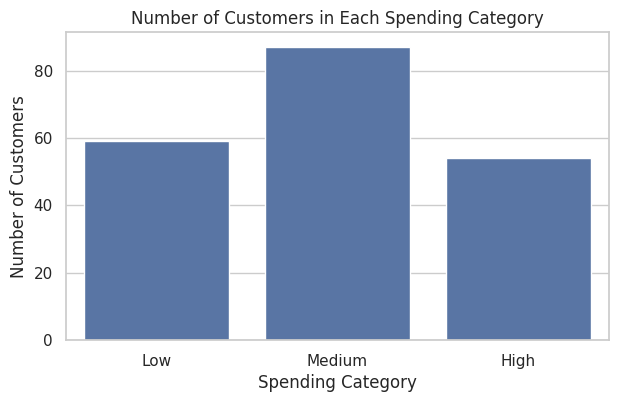

In [5]:
# Create spending categories from Spending Score (1-100).
# Low:    1-39
# Medium: 40-69
# High:   70-100

def spending_category(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df["Spending Category"] = df["Spending Score (1-100)"].apply(spending_category)

category_order = ["Low", "Medium", "High"]

print("Spending category counts:")
display(df["Spending Category"].value_counts().reindex(category_order))

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Spending Category", order=category_order)
plt.title("Number of Customers in Each Spending Category")
plt.xlabel("Spending Category")
plt.ylabel("Number of Customers")
plt.show()


## 5. Feature Selection and Train/Test Split



In [6]:
features = ["Age", "Annual Income (k$)"]
target = "Spending Category"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 150
Testing samples : 50


# 6. Accuracy vs K Analysis


,K,Accuracy
0,1,0.74
1,2,0.76
2,3,0.74
3,4,0.78
4,5,0.76
5,6,0.74
6,7,0.72
7,8,0.76
8,9,0.76
9,10,0.76


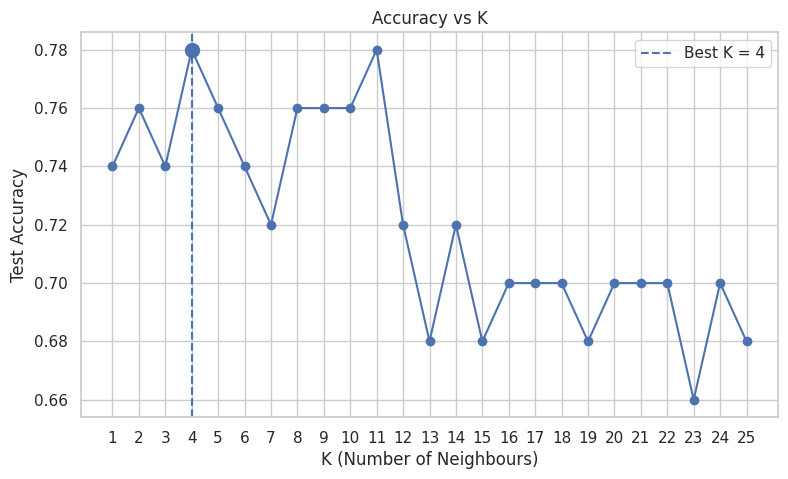

Best K based on this train/test split: K = 4
Best test accuracy: 0.7800 (78.00%)


In [7]:
k_values = list(range(1, 26))
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    k_accuracies.append(accuracy_score(y_test, pred))

results_k = pd.DataFrame({
    "K": k_values,
    "Accuracy": k_accuracies
})

best_idx = results_k["Accuracy"].idxmax()
best_k = int(results_k.loc[best_idx, "K"])
best_accuracy = float(results_k.loc[best_idx, "Accuracy"])

display(results_k)

plt.figure(figsize=(9,5))
plt.plot(results_k["K"], results_k["Accuracy"], marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best K = {best_k}")
plt.scatter([best_k], [best_accuracy], s=100, zorder=5)
plt.title("Accuracy vs K")
plt.xlabel("K (Number of Neighbours)")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.legend()
plt.show()

print(f"Best K based on this train/test split: K = {best_k}")
print(f"Best test accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")


# 7. Effect of Distance Metrics




,Distance Metric,K,Accuracy
0,euclidean,4,0.78
1,manhattan,4,0.78
2,chebyshev,4,0.76


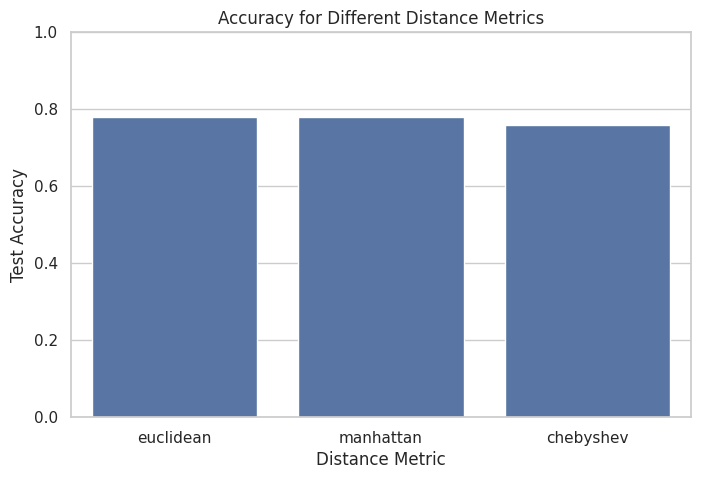

In [8]:
metrics = ["euclidean", "manhattan", "chebyshev"]
metric_results = []
metric_predictions = {}

for metric in metrics:
    model = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred, labels=category_order)

    metric_results.append({
        "Distance Metric": metric,
        "K": best_k,
        "Accuracy": acc
    })
    metric_predictions[metric] = pred

metric_results_df = pd.DataFrame(metric_results)
display(metric_results_df)

plt.figure(figsize=(8,5))
sns.barplot(data=metric_results_df, x="Distance Metric", y="Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy for Different Distance Metrics")
plt.ylabel("Test Accuracy")
plt.show()


## 8. Confusion Matrix for Each Distance Metric



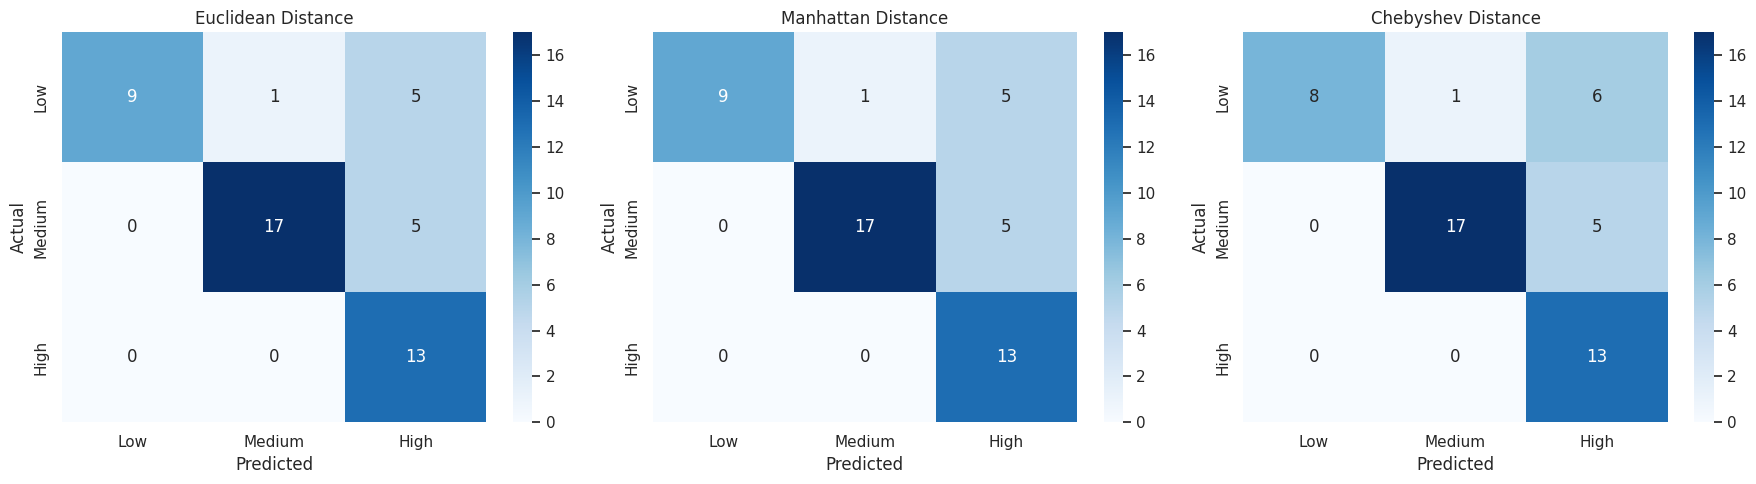

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    cm = confusion_matrix(y_test, metric_predictions[metric], labels=category_order)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=category_order,
        yticklabels=category_order,
        ax=ax
    )
    ax.set_title(f"{metric.title()} Distance")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [10]:
# Detailed reports and most-misclassified category for each metric

for metric in metrics:
    pred = metric_predictions[metric]
    cm = confusion_matrix(y_test, pred, labels=category_order)

    # Row sums = actual samples in each class
    # Subtract diagonal = incorrect predictions for that actual class
    errors_by_class = cm.sum(axis=1) - np.diag(cm)
    error_table = pd.Series(errors_by_class, index=category_order).sort_values(ascending=False)

    print("=" * 60)
    print(metric.upper())
    print("=" * 60)
    print(classification_report(y_test, pred, labels=category_order, zero_division=0))
    print("Misclassifications by actual spending category:")
    display(error_table.to_frame("Number of Misclassified Samples"))
    print("Most misclassified category:", error_table.index[0])


EUCLIDEAN
              precision    recall  f1-score   support

         Low       1.00      0.60      0.75        15
      Medium       0.94      0.77      0.85        22
        High       0.57      1.00      0.72        13

    accuracy                           0.78        50
   macro avg       0.84      0.79      0.77        50
weighted avg       0.86      0.78      0.79        50

Misclassifications by actual spending category:


,Number of Misclassified Samples
Low,6
Medium,5
High,0


Most misclassified category: Low
MANHATTAN
              precision    recall  f1-score   support

         Low       1.00      0.60      0.75        15
      Medium       0.94      0.77      0.85        22
        High       0.57      1.00      0.72        13

    accuracy                           0.78        50
   macro avg       0.84      0.79      0.77        50
weighted avg       0.86      0.78      0.79        50

Misclassifications by actual spending category:


,Number of Misclassified Samples
Low,6
Medium,5
High,0


Most misclassified category: Low
CHEBYSHEV
              precision    recall  f1-score   support

         Low       1.00      0.53      0.70        15
      Medium       0.94      0.77      0.85        22
        High       0.54      1.00      0.70        13

    accuracy                           0.76        50
   macro avg       0.83      0.77      0.75        50
weighted avg       0.86      0.76      0.77        50

Misclassifications by actual spending category:


,Number of Misclassified Samples
Low,7
Medium,5
High,0


Most misclassified category: Low


# 9. Decision Boundary Visualisation



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


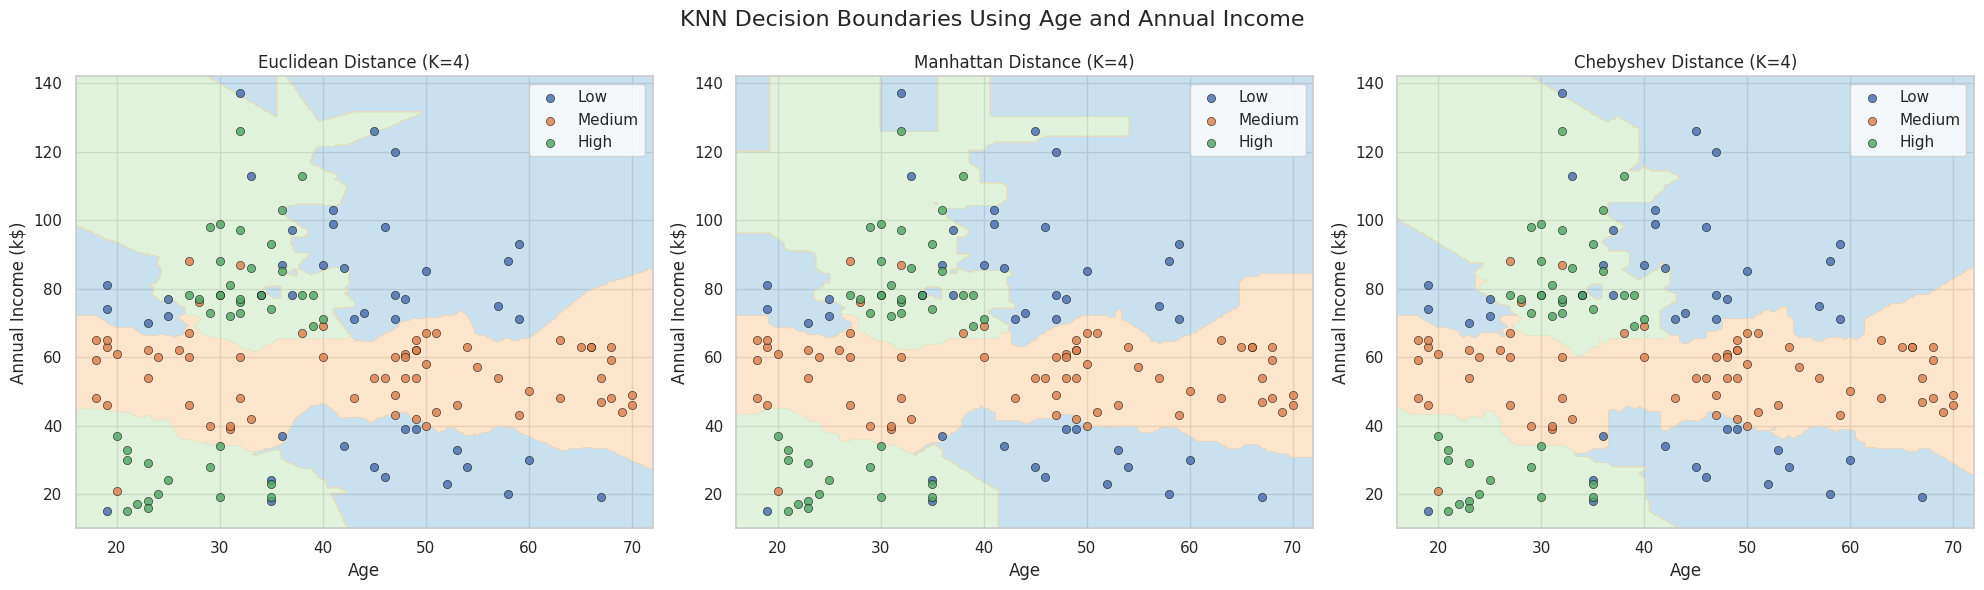

In [11]:
from matplotlib.colors import ListedColormap

class_to_num = {"Low": 0, "Medium": 1, "High": 2}
num_to_class = {v: k for k, v in class_to_num.items()}

X_train_num = np.array([class_to_num[v] for v in y_train])

def plot_decision_boundary(metric, k, ax):
    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    model.fit(X_train_scaled, y_train)

    # Grid in original feature units
    x_min, x_max = X["Age"].min() - 2, X["Age"].max() + 2
    y_min, y_max = X["Annual Income (k$)"].min() - 5, X["Annual Income (k$)"].max() + 5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_original = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_original)

    Z = model.predict(grid_scaled)
    Z_num = np.array([class_to_num[v] for v in Z]).reshape(xx.shape)

    cmap = ListedColormap(["#9ecae1", "#fdd0a2", "#c7e9c0"])
    point_colors = ["#3182bd", "#e6550d", "#31a354"]

    ax.contourf(xx, yy, Z_num, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap, alpha=0.55)

    for label, color in zip(category_order, point_colors):
        mask = y_train.values == label
        ax.scatter(
            X_train.loc[mask, "Age"],
            X_train.loc[mask, "Annual Income (k$)"],
            label=label,
            s=35,
            edgecolor="black",
            linewidth=0.4,
            alpha=0.85
        )

    ax.set_title(f"{metric.title()} Distance (K={k})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Annual Income (k$)")
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric in zip(axes, metrics):
    plot_decision_boundary(metric, best_k, ax)

plt.suptitle("KNN Decision Boundaries Using Age and Annual Income", fontsize=16)
plt.tight_layout()
plt.show()


## 10. Comparing the Decision Boundaries

The three plots show the same customers classified using different distance definitions:

- **Euclidean:** measures straight-line distance and often produces smooth neighbourhood relationships.
- **Manhattan:** measures movement along coordinate axes and can produce somewhat different regions, especially where feature differences vary.
- **Chebyshev:** depends only on the largest coordinate difference and can produce broader/square-like neighbourhood behaviour.

Because KNN is a local, distance-based algorithm, changing the metric can change which training points are considered nearest and therefore change the decision boundary.


# 11. Final Results Summary

In [12]:
best_metric_row = metric_results_df.loc[metric_results_df["Accuracy"].idxmax()]

print("========== FINAL SUMMARY ==========")
print(f"Best K: {best_k}")
print(f"Best K Accuracy (Euclidean): {best_accuracy*100:.2f}%")
print()
print("Distance metric results:")
display(metric_results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True))
print()
print(f"Best-performing distance metric: {best_metric_row['Distance Metric']}")
print(f"Best metric accuracy: {best_metric_row['Accuracy']*100:.2f}%")


========== FINAL SUMMARY ==========
Best K: 4
Best K Accuracy (Euclidean): 78.00%

Distance metric results:


,Distance Metric,K,Accuracy
0,euclidean,4,0.78
1,manhattan,4,0.78
2,chebyshev,4,0.76



Best-performing distance metric: euclidean
Best metric accuracy: 78.00%
